# getting_contours_saved_in_spatialite.ipynb

I used this notebook to learn how to use contours saved as WKB blobs in SpatiaLite.

Here the steps I want to accomplish:

1. Open a test database containing images and tree contours extracted using the SAM3 segmentation model.
2. Visually check that the that the tree contour fits the tree image
3. EFD reconstruction

## The next 3 cells show how to prevent interactions between plots when using the ipympl backend

[Reference](https://www.google.com/search?client=ubuntu-sn&channel=fs&q=prevent+interaction+between+pyplots+&udm=50&fbs=ABfTbFVyMZGZf1hfvX9uKjN_-G8c4u0nXx4bEIpwm1lnNH832SMIiTl3t-JZ4hGJOxPbHYSIu8Q64jU5EwQ-803VaKbdipNP9IdSJPNW0dZW-vtpfTgsxPubDUGnnlexyWPgXsYNlXlmyPinvUYfER67uhQ5Vfbik35T4Dg9gniUKXVW_UbnTVWpRess5NuzktlkeG__xvaIML5bSATkoDeT0MVLmDH1TQ&aep=10&ntc=1&sxsrf=APpeQnuCd_6MVXzzQxdSzWz_3X_slxLXZw%3A1786782435532&mstk=AUtExfCN6_3MDnlnjACT336tKmJmpfYkB4yE5VkAlGzRlOUwnO8Y7K1makAXMAFMvoyyIyVipf-QBT8kuKkDOo9vjuj_93BRl4DQym8gA1i-d1YBBncJw2blmnbSgqWAaPOAUZp-cgRJ-ZmwGDrZQTieTjC8nfZf70Hp5hMge9r4R2KmtA19JVPQ1Dl7gx9MXxWgQTmN1p-5zAsGGSZtk_u-cQergf_F71GV_g_BVmsoSkC8BWcQAfoPTQ1b0cAICV_T161tHSCI3CFYvQ&aioh=3&csuir=1&atvm=2&mtid=CiiAao3TLOXk2roPgs3IaQ)

Convert the cells from raw to Python to execute them.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import sqlite3
from icecream import ic
from shapely import wkb, to_wkt
from shapely.geometry import Polygon
import numpy as np
import cv2
import matplotlib.pyplot as plt
import efd_find_cuts as efd

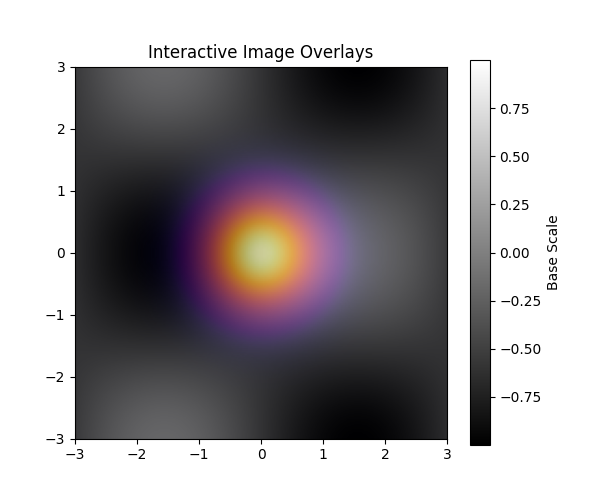

In [2]:
# %matplotlib ipympl
# import matplotlib.pyplot as plt
# import numpy as np
import ipywidgets as widgets

# 1. Generate sample data/images
x = np.linspace(-3, 3, 200)
y = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(x, y)

base_image = np.sin(X) * np.cos(Y)
overlay_1 = np.exp(-(X**2 + Y**2))           # Gaussian hotspot
overlay_2 = np.sin(np.sqrt(X**2 + Y**2))     # Circular ripple pattern

# 2. Setup Plot
fig, ax = plt.subplots(figsize=(6, 5))

# Render Base Image
im_base = ax.imshow(base_image, cmap='gray', extent=[-3, 3, -3, 3])

# Render Overlays (stored in a dictionary for easy access)
overlays = {
    'Hotspot (Gaussian)': ax.imshow(overlay_1, cmap='inferno', alpha=0.6, extent=[-3, 3, -3, 3], visible=True),
    'Ripples (Circular)': ax.imshow(overlay_2, cmap='viridis', alpha=0.6, extent=[-3, 3, -3, 3], visible=False)
}

ax.set_title("Interactive Image Overlays")
fig.colorbar(im_base, ax=ax, label="Base Scale")

# 3. Create ipywidgets Controls
checkbox_hotspot = widgets.Checkbox(value=True, description='Hotspot Layer')
checkbox_ripples = widgets.Checkbox(value=False, description='Ripples Layer')
alpha_slider = widgets.FloatSlider(value=0.6, min=0.0, max=1.0, step=0.05, description='Overlay Alpha:')

# 4. Callback Functions
def update_visibility(change):
    overlays['Hotspot (Gaussian)'].set_visible(checkbox_hotspot.value)
    overlays['Ripples (Circular)'].set_visible(checkbox_ripples.value)
    fig.canvas.draw_idle()  # Request efficient canvas update

def update_alpha(change):
    for name, im in overlays.items():
        im.set_alpha(alpha_slider.value)
    fig.canvas.draw_idle()

# Attach Observers
checkbox_hotspot.observe(update_visibility, names='value')
checkbox_ripples.observe(update_visibility, names='value')
alpha_slider.observe(update_alpha, names='value')

# 5. Display UI
controls = widgets.VBox([checkbox_hotspot, checkbox_ripples, alpha_slider])
display(controls)

# Functions

In [3]:
from typing import Any, Literal
import numpy as np
import numpy.typing as npt

# Define a type alias for the allowed return string values
DetectionResult = Literal["contour", "mask", "unknown"]


def is_contour_or_mask(obj: Any) -> DetectionResult:
    """
    Checks if an input object is a cv2 contour array or a 2D binary mask.

    Parameters
    ----------
    obj : Any
        The input object to evaluate.

    Returns
    -------
    DetectionResult
        'contour', 'mask', or 'unknown'
    """
    if not isinstance(obj, np.ndarray):
        return "unknown"

    # Type assertion for static type checkers (mypy/pyright)
    arr: npt.NDArray[Any] = obj

    # Contour check: 2D or 3D array where the last dimension is 2 (x, y coordinates)
    if arr.ndim in (2, 3) and arr.shape[-1] == 2 and arr.dtype == np.int32:
        return "contour"

    # Binary mask check: 2D image array containing at most 2 unique pixel values
    if arr.ndim == 2:
        unique_vals: npt.NDArray[Any] = np.unique(arr)
        if len(unique_vals) <= 2:
            return "mask"

    return "unknown"


# Example Usage with explicit annotations:
if __name__ == "__main__":
    contour: npt.NDArray[np.int32] = np.array([[[10, 20]], [[15, 25]], [[20, 30]]], dtype=np.int32)
    mask: npt.NDArray[np.uint8] = np.zeros((100, 100), dtype=np.uint8)
    mask[20:50, 20:50] = 255

    result_contour: DetectionResult = is_contour_or_mask(contour)
    result_mask: DetectionResult = is_contour_or_mask(mask)

    print(f"Contour test: {result_contour}")  # Output: contour
    print(f"Mask test:    {result_mask}")     # Output: mask

Contour test: contour
Mask test:    mask


In [4]:
import cv2
import numpy as np
import numpy.typing as npt


def contour_to_mask(
    contour: npt.NDArray[np.int32],
    image_shape: tuple[int, int]
) -> npt.NDArray[np.uint8]:
    """
    Renders a single OpenCV contour as a filled binary mask (0 and 255).

    Parameters
    ----------
    contour : npt.NDArray[np.int32]
        Contour coordinates array with shape (N, 1, 2) or (N, 2).
    image_shape : tuple[int, int]
        Output mask dimensions specified as (height, width).
    """
    mask: npt.NDArray[np.uint8] = np.zeros(image_shape, dtype=np.uint8)
    # thickness=-1 fills the interior of the contour
    cv2.drawContours(mask, [contour], contourIdx=-1, color=255, thickness=-1)
    return mask


def mask_to_contours(
    mask: npt.NDArray[np.uint8]
) -> tuple[npt.NDArray[np.int32], ...]:
    """
    Extracts outer contours from a 2D binary mask.

    Parameters
    ----------
    mask : npt.NDArray[np.uint8]
        Binary mask image where object pixels are non-zero.
    """
    # Ensure mask is uint8
    binary_mask = mask.astype(np.uint8)
    contours, _ = cv2.findContours(
        binary_mask,
        mode=cv2.RETR_EXTERNAL,
        method=cv2.CHAIN_APPROX_SIMPLE
    )
    return contours


# Example Usage
if __name__ == "__main__":
    shape = (200, 200)  # (height, width)

    # 1. Create a dummy square contour
    square_contour: npt.NDArray[np.int32] = np.array(
        [[[50, 50]], [[150, 50]], [[150, 150]], [[50, 150]]], dtype=np.int32
    )

    # 2. Contour -> Mask
    generated_mask = contour_to_mask(square_contour, image_shape=shape)

    # 3. Mask -> Contours
    extracted_contours = mask_to_contours(generated_mask)

    print(f"Mask created with shape: {generated_mask.shape}")
    print(f"Extracted {len(extracted_contours)} contour(s)")
    print(f"Extracted contour shape: {extracted_contours[0].shape}")

Mask created with shape: (200, 200)
Extracted 1 contour(s)
Extracted contour shape: (4, 1, 2)


In [5]:
from typing import TypedDict
import cv2
import numpy as np
import numpy.typing as npt


class ContourProperties(TypedDict):
    bbox: tuple[int, int, int, int]  # (x, y, width, height)
    area: float
    perimeter: float
    centroid: tuple[int, int] | None  # (cx, cy)


def extract_contour_properties(
    contour: npt.NDArray[np.int32]
) -> ContourProperties:
    """
    Extracts bounding box, area, perimeter, and centroid from an OpenCV contour.
    """
    # 1. Bounding Box: returns (x, y, width, height)
    x, y, w, h = cv2.boundingRect(contour)

    # 2. Area
    area: float = cv2.contourArea(contour)

    # 3. Perimeter (Arc Length); closed=True specifies a closed shape
    perimeter: float = cv2.arcLength(contour, closed=True)

    # 4. Centroid via Image Moments: cx = m10 / m00, cy = m01 / m00
    moments = cv2.moments(contour)
    if moments["m00"] != 0:
        cx = int(moments["m10"] / moments["m00"])
        cy = int(moments["m01"] / moments["m00"])
        centroid: tuple[int, int] | None = (cx, cy)
    else:
        # Handles degenerate / single-pixel contours where area (m00) is 0
        centroid = None

    return {
        "bbox": (x, y, w, h),
        "area": area,
        "perimeter": perimeter,
        "centroid": centroid,
    }


# Example Usage
if __name__ == "__main__":
    # Define a 100x100 square contour offset at (20, 30)
    square_contour: npt.NDArray[np.int32] = np.array(
        [[[20, 30]], [[120, 30]], [[120, 130]], [[20, 130]]], dtype=np.int32
    )

    props = extract_contour_properties(square_contour)

    print(f"Bounding Box (x, y, w, h): {props['bbox']}")
    print(f"Area:                     {props['area']}")
    print(f"Perimeter:                {props['perimeter']}")
    print(f"Centroid (cx, cy):        {props['centroid']}")

Bounding Box (x, y, w, h): (20, 30, 101, 101)
Area:                     10000.0
Perimeter:                400.0
Centroid (cx, cy):        (70, 80)


# 1 Open a test database

In [6]:
db_path = 'new.db'
image_id = 1
tree_id = 1
order = 20

In [7]:
conn = sqlite3.connect(db_path)   
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')
cursor = conn.cursor()

# 2. Visually check that the that the tree contour fits the tree image

ic| tree_poly_str: <POLYGON ((486 -677, 486 -682, 485 -683, 485 -687, 484 -688, 484 -689, 482 -...>
ic| tree_contour: array([[486, 677],
                         [486, 682],
                         [485, 683],
                         ...,
                         [488, 678],
                         [487, 678],
                         [486, 677]], shape=(1084, 2), dtype=int32)
ic| tree_contour.dtype: dtype('int32')
ic| type(tree_contour): <class 'numpy.ndarray'>


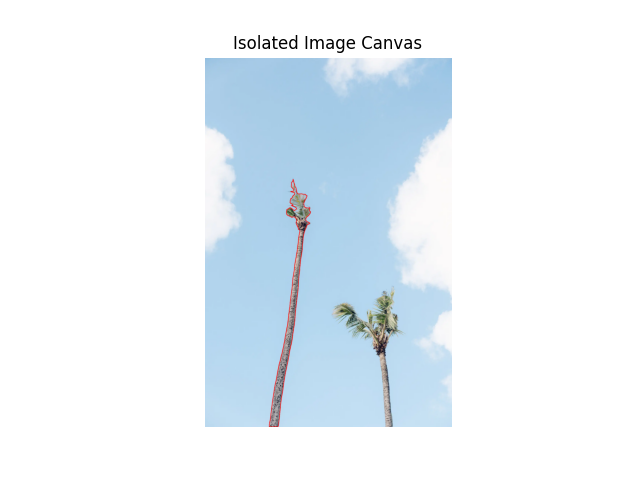

In [22]:
sql = 'SELECT image_path FROM images, trees WHERE images.image_id=trees.image_id AND tree_id=1'
image_path = cursor.execute(sql).fetchone()[0]

sql = 'SELECT AsBinary(tree_poly) FROM trees WHERE tree_id=1'
tree_poly_binary = cursor.execute(sql).fetchone()[0]
# Use Shapely to convert the WKB binary to a polygon and extract the contour coordinates
tree_poly_str = wkb.loads(tree_poly_binary)
ic(tree_poly_str)

tree_contour = np.array(tree_poly_str.exterior.coords).astype(np.int32)
tree_contour = np.abs(tree_contour) # Ensure all coordinates are positive
ic(tree_contour)
ic(tree_contour.dtype)
ic(type(tree_contour))
len(tree_contour)



# 1. Load your image file into an array
# img = mpimg.imread(image_path)

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
cv2.polylines(img, [tree_contour], color=(255,0,0), isClosed=True, thickness=2)



# 2. Setup isolated figure handle
fig, ax = plt.subplots()

# 3. Render image data on specific axis handle
ax.imshow(img)
ax.set_title("Isolated Image Canvas")

# 4. Clean window frame properties (Optional)
ax.axis('off') 

plt.show()

## Get the contour of the first tree

This is the contour calculated by SAM3 which is saved as a blob in the `tree_poly` field of the `v_tree_poly` view.

In [9]:
# cursor.execute('SELECT * FROM v_tree_poly')
# cursor.execute(f"SELECT image_width, image_height, AsBinary(tree_poly) AS tree_poly_binary FROM v_tree_poly WHERE tree_id = {tree_id}")
cursor.execute(f"""SELECT image_width, image_height, AsBinary(tree_poly) AS tree_poly_binary 
               FROM images, trees
               WHERE images.image_id=trees.image_id
               AND tree_id = {tree_id}""")
image_width, image_height, tree_poly_binary = cursor.fetchone()

# Use Shapely to convert the WKB binary to a polygon and extract the contour coordinates
tree_poly_str = wkb.loads(tree_poly_binary)
tree_contour = np.array(tree_poly_str.exterior.coords).astype(np.int32)
tree_contour = np.abs(tree_contour) # Ensure all coordinates are positive
ic(tree_contour)
ic(tree_contour.dtype)
ic(type(tree_contour))
len(tree_contour)

ic| tree_contour: array([[486, 677],
                         [486, 682],
                         [485, 683],
                         ...,
                         [488, 678],
                         [487, 678],
                         [486, 677]], shape=(1084, 2), dtype=int32)
ic| tree_contour.dtype: dtype('int32')
ic| type(tree_contour): <class 'numpy.ndarray'>


1084

# Visualize the tree contour.

In [10]:
img = mpimg.imread('data_cache/example_images/08hs-palms-03-zglw-superJumbo.webp')








# fig, ax = plt.subplots()
# tree_mask = np.zeros((image_width, image_height, 1), dtype=np.uint8)
# cv2.fillPoly(tree_mask, [tree_contour], 255)
# plt.imshow(tree_mask);

# Make sure the contour surrounds the detected tree

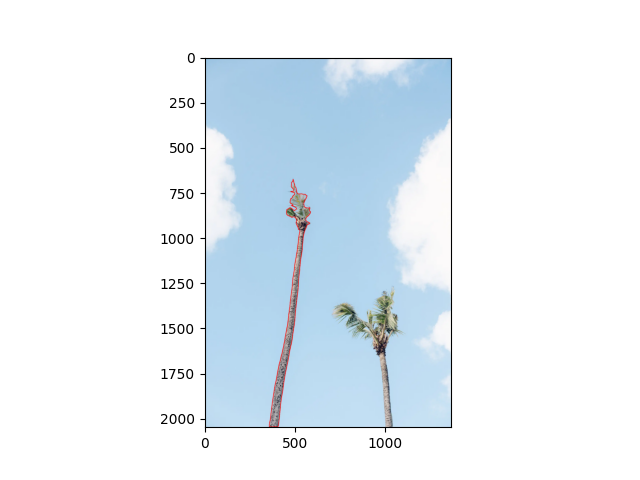

In [11]:
cursor.execute('SELECT tree_id, image_path FROM images, trees WHERE images.image_id=trees.image_id AND tree_id=1')
_, image_path = cursor.fetchone()
img = cv2.imread(image_path)
cv2.polylines(img, [tree_contour], color=(0,0,255), isClosed=True, thickness=2)
img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1,1)
plt.imshow(img);

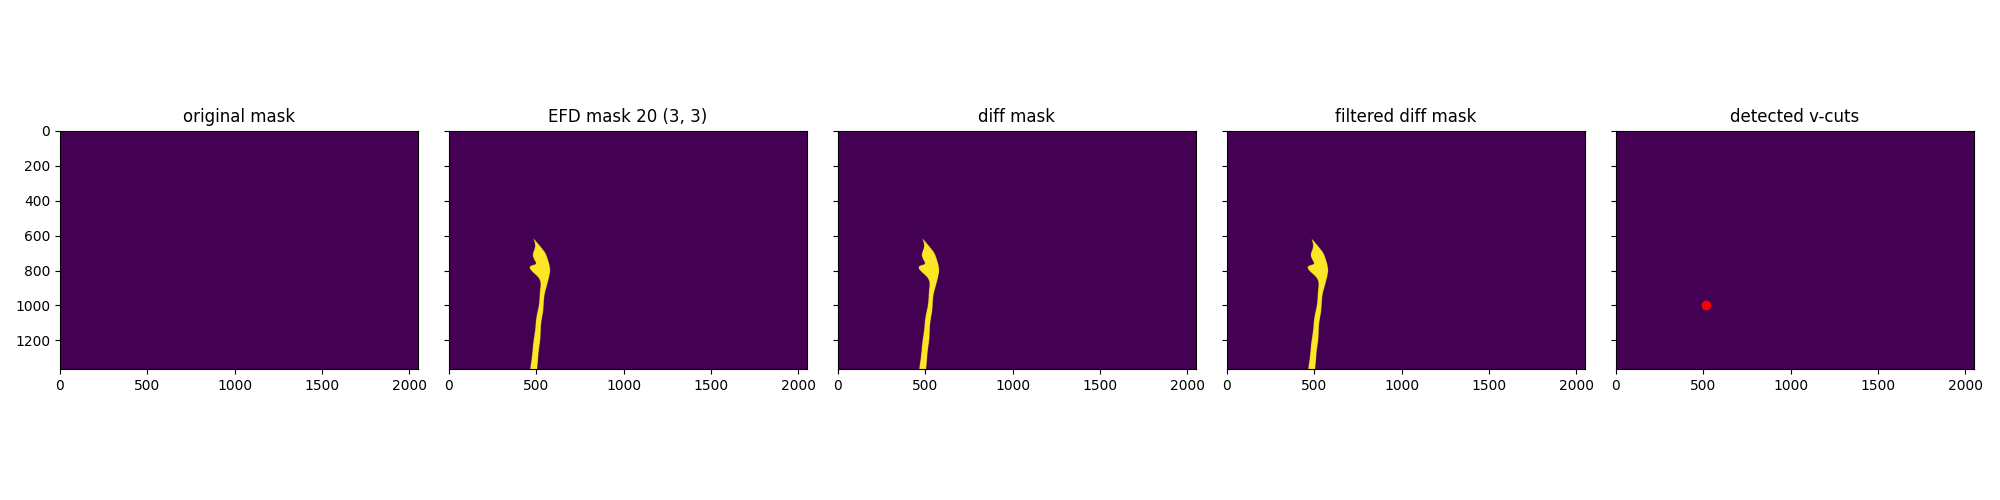

In [12]:
tree_mask = np.zeros((image_width, image_height, 1), dtype=np.uint8)

results = efd.efd_find_cuts(
    original_contour=tree_contour, 
    original_mask=tree_mask,
    order=order
    )
my_fig, my_axs = efd.plot_efd_results(results)
plt.show()

In [13]:
img = results.original_mask
cv2.fillPoly(img, results.vcut_contours, 128)
plt.imshow(img[600:1000, 250:750]);


In [14]:
for contour in results.vcut_contours:
    # convert countour to WKT format using Shapely
    squeeze_contour = np.squeeze(contour)  # Shape becomes (N, 2)
    poly = Polygon(squeeze_contour)
    wkt_string = to_wkt(poly)
    
    conn.execute(
        'INSERT INTO damage (image_id, tree_id, damage_poly) VALUES (?, ?, GeomFromText(?, 0))', 
        (image_id, tree_id, wkt_string)
    )
    
conn.commit()

# Visually check alignment of efd reconstructed poly and tree-poly

|color|var|
|--|--|
|white:|tree_contour|
|red:|aligned_recon|
|green:|raw_recon|

# !! Something weird here: "aligned_recon is misaligned" !!

# 3. EFD reconstruction

In [15]:
from pyefd import elliptic_fourier_descriptors, calculate_dc_coefficients, reconstruct_contour

img_width, img_height, _ = img.shape

original_contour=tree_contour
ic(tree_contour)

num_harmonics=order

original_contour = np.array(original_contour, dtype=np.float64).reshape(-1, 2)
ic(original_contour)

# 1. Extract descriptors (keep normalize=False to retain native spatial details)
coeffs = elliptic_fourier_descriptors(original_contour, order=num_harmonics, normalize=False)

# 2. Extract DC spatial tracking offsets
dc_coeffs = calculate_dc_coefficients(original_contour)

# 3. Generate raw reconstruction (matching original row length for point parity)
reconstructed_contour = reconstruct_contour(
    coeffs, 
    locus=dc_coeffs, 
    num_points=len(original_contour)
)

ic(original_contour.astype(np.int32));

img = np.zeros((img.shape[0], img.shape[1], 3), dtype=np.uint8)
cv2.polylines(img, pts=[original_contour.astype(np.int32)], isClosed=True, color=(255, 255, 255), thickness=2)
cv2.polylines(img, pts=[reconstructed_contour.astype(np.int32)], isClosed=True, color=(0,255,0), thickness=2)
plt.imshow(img[600:1000, 250:750]);

ic| tree_contour: array([[486, 677],
                         [486, 682],
                         [485, 683],
                         ...,
                         [488, 678],
                         [487, 678],
                         [486, 677]], shape=(1084, 2), dtype=int32)
ic| original_contour: array([[486., 677.],
                             [486., 682.],
                             [485., 683.],
                             ...,
                             [488., 678.],
                             [487., 678.],
                             [486., 677.]], shape=(1084, 2))
ic| original_contour.astype(np.int32): array([[486, 677],
                                              [486, 682],
                                              [485, 683],
                                              ...,
                                              [488, 678],
                                              [487, 678],
                                              [486, 677]], shape=(

# Now calculate mask containing pixels which are in the reconstruction mask but not in the original mask

Text(0.5, 1.0, 'diff mask')

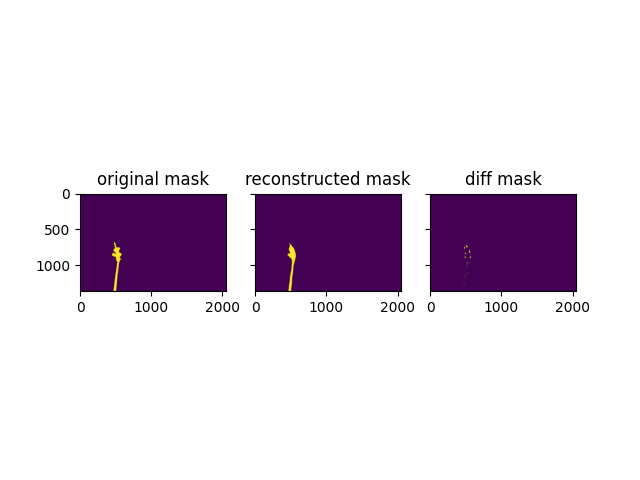

In [16]:
original_mask = np.zeros((img_width, img_height), dtype=np.uint8)
reconstructed_mask = np.zeros((img_width, img_height), dtype=np.uint8)

cv2.fillPoly(original_mask, pts=[original_contour.astype(np.int32)], color=255)
cv2.fillPoly(reconstructed_mask, pts=[reconstructed_contour.astype(np.int32)], color=255)

# Pixels missing in original, present in reconstruction
diff_mask = cv2.bitwise_and(reconstructed_mask, cv2.bitwise_not(original_mask))

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True)
axs[0].imshow(original_mask)
axs[0].set_title('original mask')
axs[1].imshow(reconstructed_mask)
axs[1].set_title('reconstructed mask')
axs[2].imshow(diff_mask)
axs[2].set_title('diff mask')
# fig.show()


In [17]:
# Save diff mask in db

diff_contours = mask_to_contours(diff_mask)
min_pixels = 100
filtered_contours = [cnt for cnt in diff_contours if cv2.contourArea(cnt) >= min_pixels]

conn.execute('DELETE FROM DAMAGE')
for cnt in filtered_contours:
    points = np.squeeze(cnt)    
    points = np.vstack((points, points[0])) # ensure first and last points are identical 
    poly = Polygon(points)
    wkt = to_wkt(poly)
    
    sql = f'INSERT INTO damage (tree_id, image_id, damage_poly) VALUES ({tree_id}, {image_id}, GeomFromText("{wkt}",0))'
    ic(sql)
    conn.execute(sql)
conn.commit()

ic| sql: 'INSERT INTO damage (tree_id, image_id, damage_poly) VALUES (1, 1, GeomFromText("POLYGON ((519 955, 519 969, 518 970, 518 977, 517 978, 517 989, 516 990, 516 1001, 515 1002, 515 1017, 514 1018, 514 1031, 514 1022, 515 1021, 515 1009, 516 1008, 516 999, 517 998, 517 995, 518 994, 518 988, 519 987, 519 983, 520 982, 520 977, 521 976, 521 972, 522 971, 522 967, 523 966, 523 959, 519 955))",0))'
ic| sql: 'INSERT INTO damage (tree_id, image_id, damage_poly) VALUES (1, 1, GeomFromText("POLYGON ((487 885, 486 886, 485 886, 484 887, 483 887, 482 888, 481 888, 485 892, 486 892, 504 910, 505 910, 505 903, 504 902, 504 898, 503 897, 503 895, 500 892, 500 891, 499 890, 498 890, 496 888, 496 887, 495 887, 493 885, 487 885))",0))'
ic| sql: 'INSERT INTO damage (tree_id, image_id, damage_poly) VALUES (1, 1, GeomFromText("POLYGON ((572 878, 568 882, 567 882, 563 886, 562 886, 562 887, 560 889, 560 891, 559 892, 559 896, 558 897, 558 903, 559 904, 559 905, 565 911, 566 911, 566 910, 567 909, 56

In [25]:
# visualize damage polygons

conn = sqlite3.connect(db_path)   
conn.enable_load_extension(True)
conn.load_extension('mod_spatialite')
cursor = conn.cursor()

# sql = 'SELECT image_path FROM images, trees WHERE images.image_id=trees.image_id AND tree_id=1'
# image_path = cursor.execute(sql).fetchone()[0]

sql = 'SELECT AsBinary(damage_poly) FROM damage WHERE damage_id=1'
damage_poly_binary = cursor.execute(sql).fetchone()[0]
# Use Shapely to convert the WKB binary to a polygon and extract the contour coordinates
damage_poly_str = wkb.loads(damage_poly_binary)
ic(damage_poly_str)

damage_contour = np.array(damage_poly_str.exterior.coords).astype(np.int32)
damage_contour = np.abs(damage_contour) # Ensure all coordinates are positive
ic(damage_contour)
ic(damage_contour.dtype)
ic(type(damage_contour))
len(damage_contour)




ic| damage_poly_str: <POLYGON ((519 955, 519 969, 518 970, 518 977, 517 978, 517 989, 516 990, 51...>
ic| damage_contour: array([[ 519,  955],
                           [ 519,  969],
                           [ 518,  970],
                           [ 518,  977],
                           [ 517,  978],
                           [ 517,  989],
                           [ 516,  990],
                           [ 516, 1001],
                           [ 515, 1002],
                           [ 515, 1017],
                           [ 514, 1018],
                           [ 514, 1031],
                           [ 514, 1022],
                           [ 515, 1021],
                           [ 515, 1009],
                           [ 516, 1008],
                           [ 516,  999],
                           [ 517,  998],
                           [ 517,  995],
                           [ 518,  994],
                           [ 518,  988],
                           [ 519,  98

32

In [ ]:
conn.close()
ic('Finished')